## Imports

In [1]:
import sys
import os
import torch
import torch.utils.data as data
import torch.nn as nn

sys.path.append(os.path.abspath('../'))

from neuro_fuzzy_toolbox import ANFIS, Hybrid_learning_algorithm, alt_SONFIS, EarlyStopping, get_measures, Gaussian_MF

In [2]:
import numpy as np

In [3]:
from sklearn.preprocessing import MinMaxScaler

# Surface (10k)

## Data

In [4]:
def z(x, y):
  return ((3) * ((1-x)**2) * (np.exp(-(x**2)-((y+1)**2))) - (10) * ((x/5)-(x**3)-(y**5)) * (np.exp(-(x**2)-(y**2))) - (1/3)*np.exp(-(x+1)**2-(y**2)))

#Training
x0 = np.random.uniform(-3,3,10000)
x1 = np.random.uniform(-3,3,10000)

e = np.random.normal(0,0.1,10000) #noise
Y = z(x0,x1) + e

#Testing
x0_test = np.random.uniform(-3,3,10000)
x1_test = np.random.uniform(-3,3,10000)

Y_test = z(x0_test,x1_test)

In [5]:
#Training
scaler = MinMaxScaler(feature_range=(0, 1))
vstack_train = np.vstack((x0,x1)).T
scaled_train = scaler.fit_transform(vstack_train)

#Testing
vstack_test = np.vstack((x0_test,x1_test)).T
scaled_test = scaler.transform(vstack_test)

In [6]:
train_loader = data.DataLoader(data.TensorDataset(torch.from_numpy(scaled_train), torch.from_numpy(Y)), batch_size = 32, shuffle = True)
x_train = train_loader.dataset.tensors[0]
y_train = train_loader.dataset.tensors[1]

x_test = torch.from_numpy(scaled_test)
y_test = torch.from_numpy(Y_test)

## Model & Training

### ANFIS

In [7]:
model = ANFIS(
    input_size = 2,
    fuzzy_rules = 1,
    outputs = 1,
    rule_reduced= True
)

In [8]:
model.init_premises(x_train)

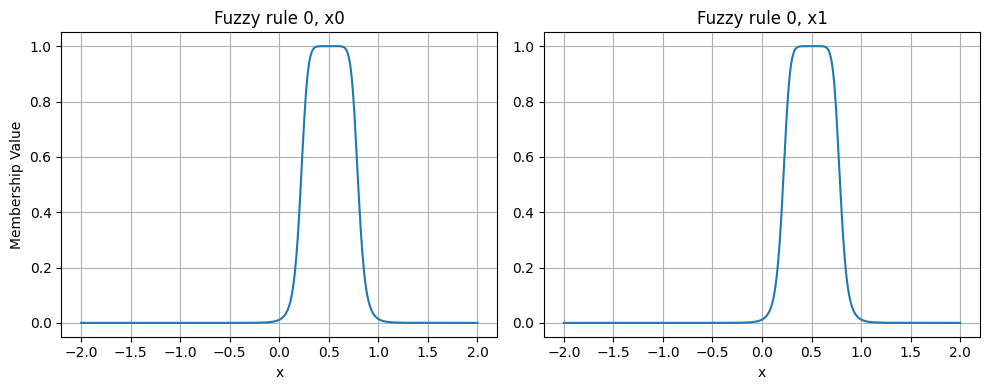

In [9]:
model.plot_premises()

### Hybrid Learning Algorithm

In [10]:
loss_fn = nn.functional.mse_loss
#loss_fn = nn.functional.binary_cross_entropy
#loss_fn = nn.functional.cross_entropy

optimizer = torch.optim.AdamW
params = {'lr': 0.001, 'weight_decay': 0.01}

early_stopping = EarlyStopping(patience=15, delta=0.01)

In [11]:
trainer = Hybrid_learning_algorithm(
    epochs=50,
    loss_function=loss_fn,
    optimizer=optimizer,
    optimizer_params=params,
    early_stopping=early_stopping
)

### SONFIS

In [12]:
Ngrow = 400
dGrow = 0.8
Nsplit = 200
eSplit = 0.5
Nvanish = 60
lVanish = 3

max_iterations = 40

anfis_trainer = trainer

validation = 0.2
sonfis_early_stopping = EarlyStopping(patience=5, delta=0.01)
last_training_iteration = True

In [13]:
sonfis = alt_SONFIS(
    Ngrow=Ngrow,
    dGrow=dGrow,
    Nsplit=Nsplit,
    eSplit=eSplit,
    Nvanish=Nvanish,
    lVanish=lVanish,
    max_iterations=max_iterations,
    ANFIStrainer=anfis_trainer,
    validation=validation,
    early_stopping=sonfis_early_stopping,
    last_training_iteration=last_training_iteration
)

In [14]:
%time sonfis(model, train_loader, verbose=True)

Iteration:  0/40 - loss: 4.619583 - validation loss: 4.648955
 -> Fuzzy rules: 2

Iteration:  1/40 - loss: 3.050953 - validation loss: 3.059268
 -> Fuzzy rules: 4

Iteration:  2/40 - loss: 1.680194 - validation loss: 1.716536
 -> Fuzzy rules: 7

Iteration:  3/40 - loss: 1.367010 - validation loss: 1.389041
 -> Fuzzy rules: 9

Iteration:  4/40 - loss: 0.842304 - validation loss: 0.818789
 -> Fuzzy rules: 10

Iteration:  5/40 - loss: 0.815870 - validation loss: 0.791055
 -> Fuzzy rules: 11

Iteration:  6/40 - loss: 0.721815 - validation loss: 0.707728
 -> Fuzzy rules: 12

Iteration:  7/40 - loss: 0.737490 - validation loss: 0.714267
 -> Fuzzy rules: 13

Iteration:  8/40 - loss: 0.721466 - validation loss: 0.701051
 -> Fuzzy rules: 13

Iteration:  9/40 - loss: 0.713689 - validation loss: 0.692393
 -> Fuzzy rules: 12

Iteration: 10/40 - loss: 0.766092 - validation loss: 0.756235
 -> Fuzzy rules: 13

Iteration: 11/40 - loss: 0.745242 - validation loss: 0.729557
 -> Fuzzy rules: 14

Iteratio

In [15]:
x_test = test_loader.dataset.tensors[0]
y_test = test_loader.dataset.tensors[1]

test_measures = get_measures(model, x_test, y_test)

for measure in test_measures:
    print(measure + ':', test_measures[measure])

MSE: 0.009111958599797602
RMSE: 0.09545657965691837
MAE: 0.06820062328487425
R2: 0.9974247272970583
MAPE: 6.611780991831554


In [16]:
train_measures = get_measures(model, x_train, y_train)

for measure in train_measures:
    print(measure + ':', train_measures[measure])

MSE: 0.019006067699993433
RMSE: 0.13786249562514613
MAE: 0.10785384803020984
R2: 0.9949432963246952
MAPE: 1.360061187718167


# Surface (1k)

In [17]:
def z(x, y):
  return ((3) * ((1-x)**2) * (np.exp(-(x**2)-((y+1)**2))) - (10) * ((x/5)-(x**3)-(y**5)) * (np.exp(-(x**2)-(y**2))) - (1/3)*np.exp(-(x+1)**2-(y**2)))

#Training
x0 = np.random.uniform(-3,3,1000)
x1 = np.random.uniform(-3,3,1000)

e = np.random.normal(0,0.1,1000) #noise
Y = z(x0,x1) + e

#Testing
x0_test = np.random.uniform(-3,3,1000)
x1_test = np.random.uniform(-3,3,1000)

Y_test = z(x0_test,x1_test)

In [18]:
#Training
scaler = MinMaxScaler(feature_range=(0, 1))
vstack_train = np.vstack((x0,x1)).T
scaled_train = scaler.fit_transform(vstack_train)

#Testing
vstack_test = np.vstack((x0_test,x1_test)).T
scaled_test = scaler.transform(vstack_test)

In [19]:
train_loader = data.DataLoader(data.TensorDataset(torch.from_numpy(scaled_train), torch.from_numpy(Y)), batch_size = 16, shuffle = True)
x_train = train_loader.dataset.tensors[0]
y_train = train_loader.dataset.tensors[1]

test_loader = data.DataLoader(data.TensorDataset(torch.from_numpy(scaled_test), torch.from_numpy(Y_test)), batch_size = 16, shuffle = True)
x_test = test_loader.dataset.tensors[0]
y_test = test_loader.dataset.tensors[1]

## Model & Training

### ANFIS

In [20]:
model = ANFIS(
    input_size = 2,
    fuzzy_rules = 1,
    outputs = 1,
    rule_reduced = True
)

In [21]:
model.init_premises(x_train)

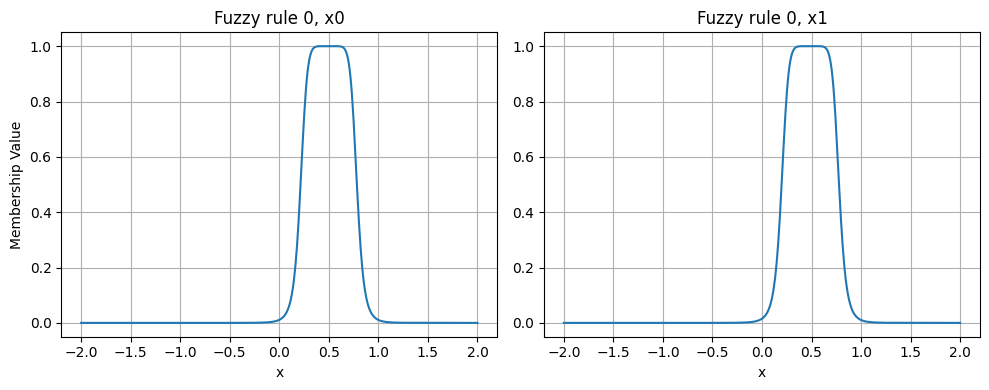

In [22]:
model.plot_premises()

### Hybrid Learning Algorithm

In [23]:
loss_fn = nn.functional.mse_loss
#loss_fn = nn.functional.binary_cross_entropy
#loss_fn = nn.functional.cross_entropy

optimizer = torch.optim.AdamW
params = {'lr': 0.001, 'weight_decay': 0.01}

early_stopping = EarlyStopping(patience=15, delta=0.01)

In [24]:
trainer = Hybrid_learning_algorithm(
    epochs=50,
    loss_function=loss_fn,
    optimizer=optimizer,
    optimizer_params=params,
    early_stopping=early_stopping
)

### SONFIS

In [25]:
Ngrow = 400
dGrow = 0.8
Nsplit = 200
eSplit = 0.5
Nvanish = 60
lVanish = 3

max_iterations = 40

anfis_trainer = trainer

validation = 0.2
sonfis_early_stopping = EarlyStopping(patience=5, delta=0.01)
last_training_iteration = True

In [26]:
sonfis = alt_SONFIS(
    Ngrow=Ngrow,
    dGrow=dGrow,
    Nsplit=Nsplit,
    eSplit=eSplit,
    Nvanish=Nvanish,
    lVanish=lVanish,
    max_iterations=max_iterations,
    ANFIStrainer=anfis_trainer,
    validation=validation,
    early_stopping=sonfis_early_stopping,
    last_training_iteration=last_training_iteration
)

In [27]:
%time sonfis(model, train_loader, verbose=True)

Iteration:  0/40 - loss: 3.328910 - validation loss: 4.296920
 -> Fuzzy rules: 2

Iteration:  1/40 - loss: 1.686439 - validation loss: 2.076409
 -> Fuzzy rules: 3

Iteration:  2/40 - loss: 1.501425 - validation loss: 1.918713
 -> Fuzzy rules: 4

Iteration:  3/40 - loss: 0.927973 - validation loss: 1.215214
 -> Fuzzy rules: 5

Iteration:  4/40 - loss: 0.420244 - validation loss: 0.625050
 -> Fuzzy rules: 5

Iteration:  5/40 - loss: 0.340004 - validation loss: 0.444779
 -> Fuzzy rules: 6

Iteration:  6/40 - loss: 0.316082 - validation loss: 0.414265
 -> Fuzzy rules: 6

Iteration:  7/40 - loss: 0.301572 - validation loss: 0.383522
 -> Fuzzy rules: 6

Iteration:  8/40 - loss: 0.242721 - validation loss: 0.324323
 -> Fuzzy rules: 6

Iteration:  9/40 - loss: 0.264916 - validation loss: 0.314235
 -> Fuzzy rules: 6

Iteration: 10/40 - loss: 0.240640 - validation loss: 0.296731
 -> Fuzzy rules: 6

Iteration: 11/40 - loss: 0.239674 - validation loss: 0.289772
 -> Fuzzy rules: 6

Iteration: 12/40

In [28]:
x_test = test_loader.dataset.tensors[0]
y_test = test_loader.dataset.tensors[1]

test_measures = get_measures(model, x_test, y_test)

for measure in test_measures:
    print(measure + ':', test_measures[measure])

MSE: 0.040822625084630595
RMSE: 0.20204609643502294
MAE: 0.14430632535443003
R2: 0.9880647048112376
MAPE: 43.59801689469408


In [29]:
train_measures = get_measures(model, x_train, y_train)

for measure in train_measures:
    print(measure + ':', train_measures[measure])

MSE: 0.04532206096999781
RMSE: 0.21288978596916716
MAE: 0.15931467663143675
R2: 0.9872562344798963
MAPE: 1.5756985876782779


# Synt 1

## Data

In [30]:
def f(x0, x1, x2):
    return (1 + x0**0.5 + x1 + x2**-1.5)

#Training
x0 = np.random.uniform(1,6,216)
x1 = np.random.uniform(1,6,216)
x2 = np.random.uniform(1,6,216)

Y = f(x0, x1, x2)


#Testing
x0_test = np.random.uniform(1.5,5.5,125)
x1_test = np.random.uniform(1.5,5.5,125)
x2_test = np.random.uniform(1.5,5.5,125)

Y_test = f(x0_test, x1_test, x2_test)

In [31]:
#Training
scaler = MinMaxScaler(feature_range=(0, 1))
vstack_train = np.vstack((x0, x1, x2)).T
scaled_train = scaler.fit_transform(vstack_train)

#Testing
vstack_test = np.vstack((x0_test,x1_test,x2_test)).T
scaled_test = scaler.transform(vstack_test)

In [32]:
loader = data.DataLoader(data.TensorDataset(torch.from_numpy(scaled_train), torch.from_numpy(Y)), batch_size = 16, shuffle = True)
x_train = loader.dataset.tensors[0]
y_train = loader.dataset.tensors[1]

## Model & Training

### ANFIS

In [33]:
model = ANFIS(
    input_size = 3,
    fuzzy_rules = 1,
    outputs = 1,
    rule_reduced=True
)

model.init_premises(x_train)

### Hybrid Learning Algorithm

In [34]:
loss_fn = nn.functional.mse_loss
#loss_fn = nn.functional.binary_cross_entropy
#loss_fn = nn.functional.cross_entropy

optimizer = torch.optim.AdamW
params = {'lr': 0.0001, 'weight_decay': 0.001}

early_stopping = EarlyStopping(patience=10, delta=0.01)

In [35]:
trainer = Hybrid_learning_algorithm(
    epochs=50,
    loss_function=loss_fn,
    optimizer=optimizer,
    optimizer_params=params,
    early_stopping=early_stopping
)

### SONFIS

In [36]:
Ngrow = 30
dGrow = 0.8
Nsplit = 40
eSplit = 0.5
Nvanish = 30
lVanish = 2

max_iterations = 40

anfis_trainer = trainer

validation = 0.2
sonfis_early_stopping = EarlyStopping(patience=5, delta=0.01)
last_training_iteration = True

In [37]:
sonfis = alt_SONFIS(
    Ngrow=Ngrow,
    dGrow=dGrow,
    Nsplit=Nsplit,
    eSplit=eSplit,
    Nvanish=Nvanish,
    lVanish=lVanish,
    max_iterations=max_iterations,
    ANFIStrainer=anfis_trainer,
    validation=validation,
    early_stopping=sonfis_early_stopping,
    last_training_iteration=last_training_iteration
)

In [38]:
%time sonfis(model, loader, verbose=True)

Iteration:  0/40 - loss: 35.501923 - validation loss: 32.133150
 -> Fuzzy rules: 2

Iteration:  1/40 - loss: 0.023602 - validation loss: 0.023233
 -> Fuzzy rules: 3

Iteration:  2/40 - loss: 0.083128 - validation loss: 0.056858
 -> Fuzzy rules: 4

Iteration:  3/40 - loss: 0.063968 - validation loss: 0.044254
 -> Fuzzy rules: 5

Iteration:  4/40 - loss: 0.058371 - validation loss: 0.041310
 -> Fuzzy rules: 5

No more updates
Iteration:  5/40 - loss: 0.058371 - validation loss: 0.041310

Training finished
 -> Fuzzy rules: 5

CPU times: user 4.61 s, sys: 12.7 ms, total: 4.62 s
Wall time: -4.89e+09 ns


In [39]:
x_test = torch.from_numpy(scaled_test)
y_test = torch.from_numpy(Y_test)

test_measures = get_measures(model, x_test, y_test)

for measure in test_measures:
    print(measure + ':', test_measures[measure])

MSE: 0.00261433769899942
RMSE: 0.0511305945496375
MAE: 0.0371564279075084
R2: 0.9983252124594013
MAPE: 0.00595488115305342


In [40]:
train_measures = get_measures(model, x_train, y_train)

for measure in train_measures:
    print(measure + ':', train_measures[measure])

MSE: 0.004844607855448718
RMSE: 0.06960321727800173
MAE: 0.04917619373138523
R2: 0.9981105729038366
MAPE: 0.00763884310570153


# Synt 2

## Data

In [167]:
def f(x1, x2):
    return ((np.sin(x1)*np.sin(x2))/(x1*x2))

#Training
x1 = np.random.uniform(-5,5,196)
x2 = np.random.uniform(-5,5,196)

#noise and outliers
epsilon = 0.5

G = np.random.normal(0, 0.01, 196)
H = np.random.normal(0, 0.05, 196)
F = G * (1 - epsilon) + epsilon * H

Y = f(x1, x2) + F


#Testing
x1_test = np.random.uniform(-5,5,392)
x2_test = np.random.uniform(-5,5,392)

Y_test = f(x1_test, x2_test)

In [168]:
#Training
scaler = MinMaxScaler(feature_range=(-1, 1))
vstack_train = np.vstack((x1, x2)).T
scaled_train = scaler.fit_transform(vstack_train)

#Testing
vstack_test = np.vstack((x1_test,x2_test)).T
scaled_test = scaler.transform(vstack_test)

In [169]:
loader = data.DataLoader(data.TensorDataset(torch.from_numpy(scaled_train), torch.from_numpy(Y)), batch_size = 16, shuffle = True)
x_train = loader.dataset.tensors[0]
y_train = loader.dataset.tensors[1]

In [170]:
x_train.shape

torch.Size([196, 2])

## Model & Training

### ANFIS

In [171]:
model = ANFIS(
    input_size = 2,
    fuzzy_rules = 1,
    outputs = 1,
    rule_reduced=True,
    membership_function=Gaussian_MF
)

model.init_premises(x_train)

### Hybrid Learning Algorithm

In [172]:
loss_fn = nn.functional.mse_loss
#loss_fn = nn.functional.binary_cross_entropy
#loss_fn = nn.functional.cross_entropy

optimizer = torch.optim.AdamW
params = {'lr': 0.001, 'weight_decay': 0.01}

early_stopping = EarlyStopping(patience=10, delta=0.01)

In [173]:
trainer = Hybrid_learning_algorithm(
    epochs=10,
    loss_function=loss_fn,
    optimizer=optimizer,
    optimizer_params=params,
    early_stopping=early_stopping
)

### SONFIS

In [174]:
Ngrow = 20
dGrow = 0.8
Nsplit = 30
eSplit = 0.7
Nvanish = 20
lVanish = 2

max_iterations = 40

anfis_trainer = trainer

validation = 0.2
sonfis_early_stopping = EarlyStopping(patience=7, delta=0.01)
last_training_iteration = True

In [175]:
sonfis = alt_SONFIS(
    Ngrow=Ngrow,
    dGrow=dGrow,
    Nsplit=Nsplit,
    eSplit=eSplit,
    Nvanish=Nvanish,
    lVanish=lVanish,
    max_iterations=max_iterations,
    ANFIStrainer=anfis_trainer,
    validation=validation,
    early_stopping=sonfis_early_stopping,
    last_training_iteration=last_training_iteration
)

In [176]:
%time sonfis(model, loader, verbose=True)

Iteration:  0/40 - loss: 0.245274 - validation loss: 0.256099
 -> Fuzzy rules: 2

Iteration:  1/40 - loss: 8.346264 - validation loss: 8.609796
 -> Fuzzy rules: 4

Iteration:  2/40 - loss: 3.660948 - validation loss: 3.706021
 -> Fuzzy rules: 6

Iteration:  3/40 - loss: 1.920380 - validation loss: 2.325092
 -> Fuzzy rules: 7

Iteration:  4/40 - loss: 0.700778 - validation loss: 0.988653
 -> Fuzzy rules: 7

Iteration:  5/40 - loss: 0.089716 - validation loss: 0.073333
 -> Fuzzy rules: 8

Iteration:  6/40 - loss: 0.093458 - validation loss: 0.079480
 -> Fuzzy rules: 7

Iteration:  7/40 - loss: 0.290436 - validation loss: 0.213216
 -> Fuzzy rules: 8

Iteration:  8/40 - loss: 0.125982 - validation loss: 0.065487
 -> Fuzzy rules: 7

Iteration:  9/40 - loss: 0.575630 - validation loss: 0.375419
 -> Fuzzy rules: 6

Iteration: 10/40 - loss: 0.149030 - validation loss: 0.161771
 -> Fuzzy rules: 7

Iteration: 11/40 - loss: 0.145613 - validation loss: 0.149240
 -> Fuzzy rules: 7

Early stopping



In [177]:
model.fuzzy_rules

7

In [178]:
x_test = torch.from_numpy(scaled_test)
y_test = torch.from_numpy(Y_test)

test_measures = get_measures(model, x_test, y_test)

for measure in test_measures:
    print(measure + ':', test_measures[measure])

MSE: 0.004359518086508372
RMSE: 0.06602664679134003
MAE: 0.05181621225606884
R2: 0.9422932384580471
MAPE: 2.22361108498403


In [179]:
train_measures = get_measures(model, x_train, y_train)

for measure in train_measures:
    print(measure + ':', train_measures[measure])

MSE: 0.003194893071824488
RMSE: 0.05652338517661949
MAE: 0.04254630786007746
R2: 0.9582277030332489
MAPE: 1.4524249830989662
